# Energy Consumption Forecasting

This notebook builds and evaluates time-series models for household electricity consumption forecasting, including feature analysis and anomaly-aware improvement.


# Energy Forecasting Report

## Time-Series Forecasting

### Step 1: Problem Definition & Data Collection
This project's goal is to use time-series modelling techniques to forecast household electricity consumption.

The "Individual household electric power consumption" dataset, which is accessible to the general public via the UCI Machine Learning Repository, was utilised. It contains over 2 million measurements of electric power consumption collected at one-minute intervals.
- **Goal:**

Using past consumption and time-based trends, forecast the Global_active_power consumption (in kilowatts) for the upcoming hour.


In [ ]:
# Step 0: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import zipfile
import urllib.request
import xgboost as xgb

# Step 1: Download & extract dataset
print("Downloading dataset...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
filename = "household_power_consumption.zip"
urllib.request.urlretrieve(url, filename)
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall()
print("Download and extraction done.")
df = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False, na_values='?')

Download and extraction done.


### Step 2: Exploratory Data Analysis (EDA) & Visualization
- The Time Series Plot showed trends, seasonality, and spikes.
- The histogram showed a skewed distribution, which meant that low consumption happened often.
- Boxplot showed the outliers in the data set.
- The Correlation Matrix showed how power-related variables were linked.
- There were seasonal patterns, with more use at certain times and days.
- During preprocessing, we also counted and dealt with missing values.
- For visualization, minimal datetime parsing and hourly resampling were applied. Full preprocessing steps (e.g., scaling, lag features) are done in Step 3."


/tmp/ipython-input-2-2125738488.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean().dropna()



--- Exploratory Data Analysis ---

Descriptive statistics of Global_active_power:
count    34168.000000
mean         1.091728
std          0.897619
min          0.124000
25%          0.341925
50%          0.802850
75%          1.579342
max          6.560533
Name: Global_active_power, dtype: float64


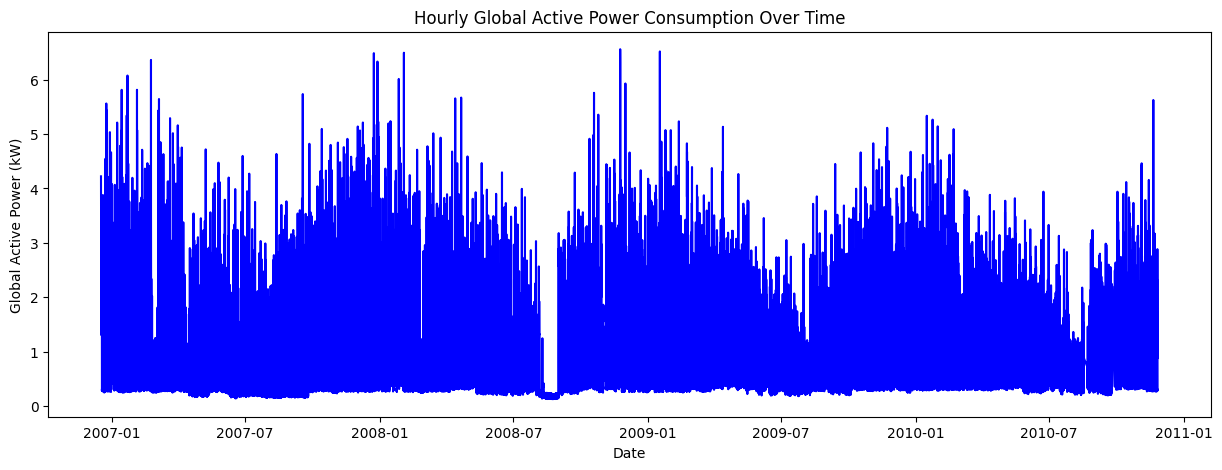

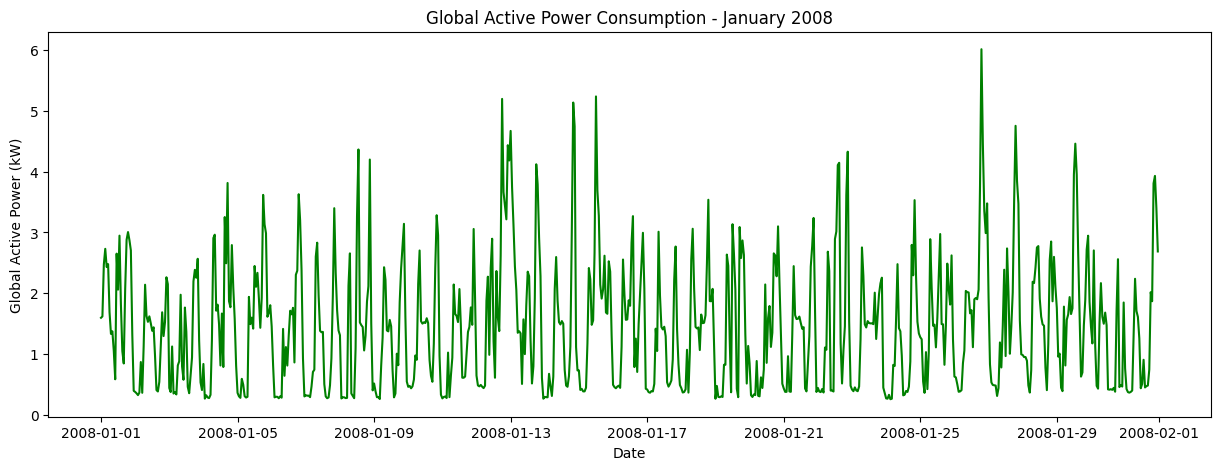

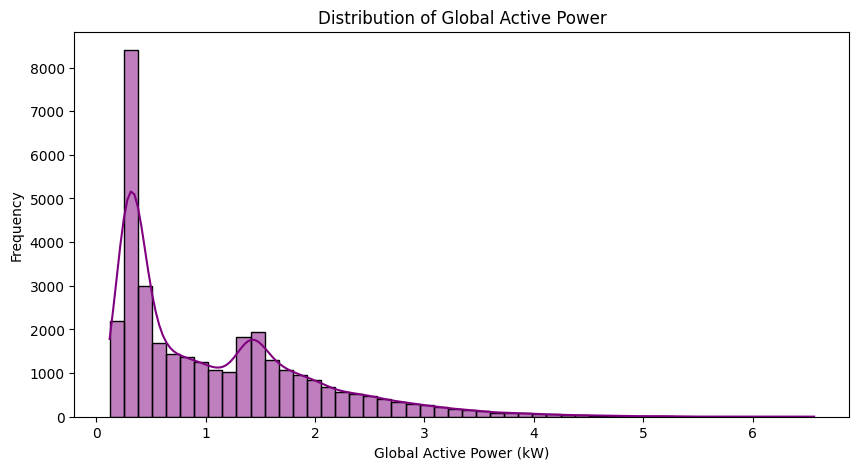

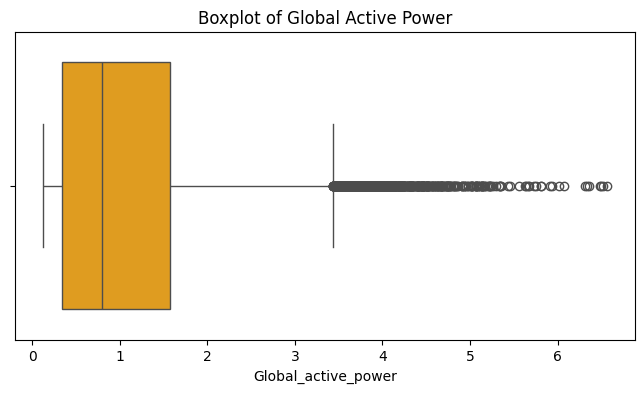

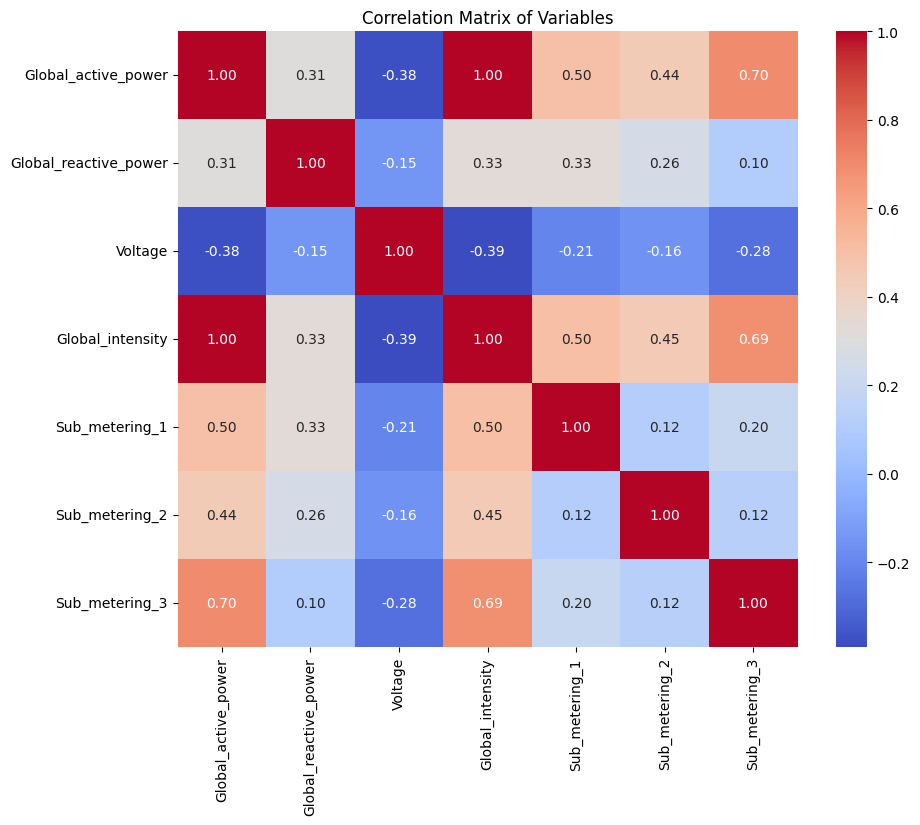

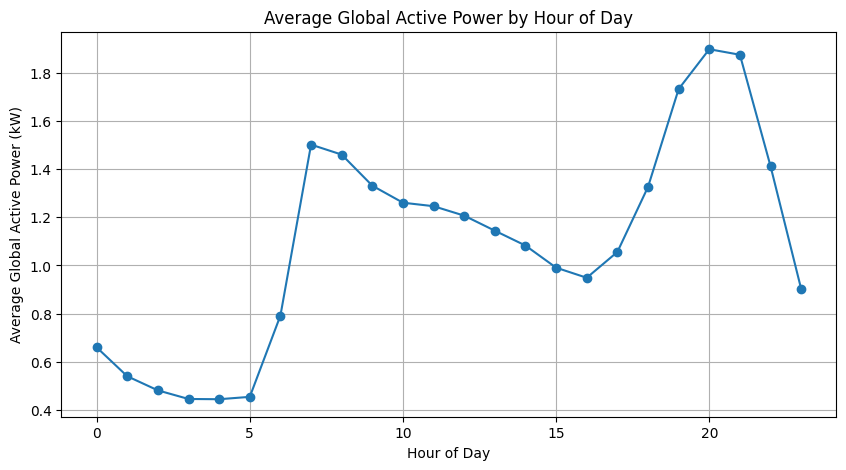

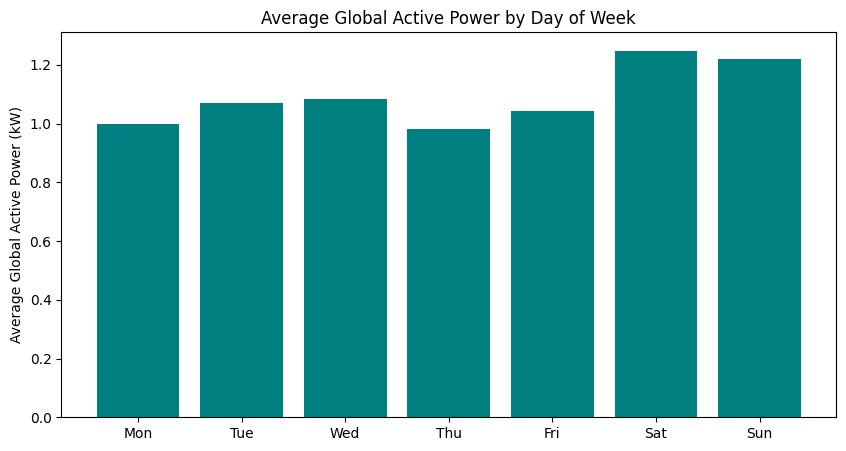


Total missing values in original dataset before resampling: 181853


In [ ]:
# Just Resampling were applied for minimal Visualization
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

# Convert all columns to numeric (force coercion of non-numeric)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_hourly = df.resample('H').mean().dropna()

# === Step 2: Exploratory Data Analysis (EDA) & Visualization ===

print("\n--- Exploratory Data Analysis ---\n")

# 1. Basic statistics summary
print("Descriptive statistics of Global_active_power:")
print(df_hourly['Global_active_power'].describe())

# 2. Plot time series of the target variable
plt.figure(figsize=(15,5))
plt.plot(df_hourly.index, df_hourly['Global_active_power'], color='blue')
plt.title('Hourly Global Active Power Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.show()

# 3. Zoom into a month (January 2008) to see detailed fluctuations
jan_2008 = df_hourly['2008-01-01':'2008-01-31']
plt.figure(figsize=(15,5))
plt.plot(jan_2008.index, jan_2008['Global_active_power'], color='green')
plt.title('Global Active Power Consumption - January 2008')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.show()

# 4. Histogram and distribution
plt.figure(figsize=(10,5))
sns.histplot(df_hourly['Global_active_power'], bins=50, kde=True, color='purple')
plt.title('Distribution of Global Active Power')
plt.xlabel('Global Active Power (kW)')
plt.ylabel('Frequency')
plt.show()

# 5. Boxplot to check outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df_hourly['Global_active_power'], color='orange')
plt.title('Boxplot of Global Active Power')
plt.show()

# 6. Heatmap of correlation between main variables
plt.figure(figsize=(10,8))
sns.heatmap(df_hourly.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Variables')
plt.show()

# 7. Seasonality check: average hourly usage by hour of day
df_hourly['Hour'] = df_hourly.index.hour
avg_hour = df_hourly.groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_hour.index, avg_hour.values, marker='o')
plt.title('Average Global Active Power by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kW)')
plt.grid(True)
plt.show()

# 8. Seasonality check: average daily usage by day of week
df_hourly['DayOfWeek'] = df_hourly.index.dayofweek
avg_day = df_hourly.groupby('DayOfWeek')['Global_active_power'].mean()

plt.figure(figsize=(10,5))
plt.bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], avg_day.values, color='teal')
plt.title('Average Global Active Power by Day of Week')
plt.ylabel('Average Global Active Power (kW)')
plt.show()

# 9. Check missing data count before resampling
missing_before = df.isna().sum().sum()
print(f"\nTotal missing values in original dataset before resampling: {missing_before}")

### Step 3: Preprocessing & Feature Engineering
- The data was resampled over an hour.
- We removed the missing values.
- We used MinMaxScaler to scale the features.
- We made cyclical features that change over time.
- We added lag features and rolling statistics

With the use of lags and rolling statistics, these engineered features aid in capturing both short-term dependencies and longer-term seasonal behaviour.


In [ ]:
#step 3 Preprocessing done in above code for visualization & Feature Engineering

feature = 'Global_active_power'
values = df_hourly[[feature]]
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values)

# Step 6: Create sequences for LSTM
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 24
X_seq, y_seq = create_sequences(scaled_values, SEQ_LENGTH)

# Step 7: Train-test split (80%-20%)
split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

# --- Add cyclical time features ---
df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly.index.hour / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly.index.hour / 24)
df_hourly['dayofweek_sin'] = np.sin(2 * np.pi * df_hourly.index.dayofweek / 7)
df_hourly['dayofweek_cos'] = np.cos(2 * np.pi * df_hourly.index.dayofweek / 7)

# --- Add rolling mean and std ---
df_hourly['rolling_mean_24'] = df_hourly['Global_active_power'].rolling(window=24).mean()
df_hourly['rolling_std_24'] = df_hourly['Global_active_power'].rolling(window=24).std()

df_hourly_feat = df_hourly.dropna()

# --- Create lag features including new features ---
def create_lag_features_with_time(df, target_col='Global_active_power', lag=24):
    df_lag = pd.DataFrame()
    for i in range(1, lag + 1):
        df_lag[f'lag_{i}'] = df[target_col].shift(i)

    df_lag['hour_sin'] = df['hour_sin']
    df_lag['hour_cos'] = df['hour_cos']
    df_lag['dayofweek_sin'] = df['dayofweek_sin']
    df_lag['dayofweek_cos'] = df['dayofweek_cos']
    df_lag['rolling_mean_24'] = df['rolling_mean_24']
    df_lag['rolling_std_24'] = df['rolling_std_24']

    df_lag['target'] = df[target_col]
    df_lag.dropna(inplace=True)
    return df_lag

df_lags_feat = create_lag_features_with_time(df_hourly_feat, lag=SEQ_LENGTH)

### Step 4: Data Splitting
Data was splitted into 80-20 rule was used to divide the data:

- The first 80% of the time series data is the training set.
- The remaining 20% is the testing set.

Regarding LSTM:

- To predict the next hour, supervised sequences of 24 input hours were created.

Regarding XGBoost:

- Directly used rolling, cyclical, and lag features as input.


In [ ]:
# Train/test split (80/20)
train_lags_feat = df_lags_feat.iloc[:int(len(df_lags_feat)*0.8)]
test_lags_feat = df_lags_feat.iloc[int(len(df_lags_feat)*0.8):]

X_train_lag_feat = train_lags_feat.drop(columns='target').values
y_train_lag_feat = train_lags_feat['target'].values
X_test_lag_feat = test_lags_feat.drop(columns='target').values
y_test_lag_feat = test_lags_feat['target'].values


### Step 5: Model Selection & Training

Two models were chosen and trained in order to be compared:


- **Model 1:** LSTM model using TensorFlow

- sequential model that includes:

   - One layer of LSTM (50 units, ReLU)

   - One layer of dense output

   - Trained with a batch size of 32 over 20 epochs.

- **Model 2:**XGBoost Regressor (Tree-Based Model)

- Trained using lag features that were engineered.

    Specifications:

    - Two hundred estimators

    - Maximum depth: 5.

    - 0.05 is the learning rate.


In [ ]:
# Step 8: Build and train LSTM
X_train_lstm = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_test_lstm = X_test_seq.reshape((X_test_seq.shape[0], X_test_seq.shape[1], 1))
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(SEQ_LENGTH, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

print("\nTraining LSTM model...")
history_lstm = lstm_model.fit(
    X_train_lstm, y_train_seq,
    epochs=20, batch_size=32, validation_split=0.1, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM model...
Epoch 1/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.0156 - val_loss: 0.0128
Epoch 2/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 0.0097 - val_loss: 0.0100
Epoch 3/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0095 - val_loss: 0.0097
Epoch 4/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0092 - val_loss: 0.0098
Epoch 5/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0094 - val_loss: 0.0096
Epoch 6/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0089 - val_loss: 0.0101
Epoch 7/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0087 - val_loss: 0.0094
Epoch 8/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0087 - val_loss: 0.0094
Epoch 9/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0088 - val_loss: 0.0095
Epoch 10/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0088 - val_loss: 0.0095
Epoch 11/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0087 - val_loss: 0.0092
Epoch 12

In [ ]:
# Build and Train XGBoost
xgb_model_feat = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

print("\nTraining improved XGBoost model with engineered features...")
xgb_model_feat.fit(X_train_lag_feat, y_train_lag_feat)
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_pred_xgb_feat = xgb_model_feat.predict(X_test_lag_feat)


Training improved XGBoost model with engineered features...
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


### Step 6: Model Evaluation
- Metrics used to compare is MAE, RMSE
- Visual plot of Actual vs Predicted (LSTM vs XGBoost)


In [ ]:
# Step 11: Inverse scaling to original scale
y_test_inv = scaler.inverse_transform(y_test_seq.reshape(-1,1))
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)
y_test_lag_feat_inv = scaler.inverse_transform(y_test_lag_feat.reshape(-1,1))
y_pred_xgb_feat_inv = scaler.inverse_transform(y_pred_xgb_feat.reshape(-1,1))

def eval_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} - MAE: {mae:.3f}, RMSE: {rmse:.3f}")
    return mae, rmse

print("\nModel Evaluation on Test Set:")
mae_lstm, rmse_lstm = eval_metrics(y_test_inv, y_pred_lstm_inv, "LSTM")
mae_xgb_feat, rmse_xgb_feat = eval_metrics(y_test_lag_feat_inv, y_pred_xgb_feat_inv, "XGBoost (Improved)")



Model Evaluation on Test Set:
LSTM - MAE: 0.369, RMSE: 0.514
XGBoost (Improved) - MAE: 2.058, RMSE: 2.928


### Performance Comparison

| Model                             | MAE       | RMSE      |
|----------------------------------|-----------|-----------|
| **LSTM**  | **0.369**  | **0.514**  |
| **XGBoost (Improved)** | **2.058**  | **2.928**  |

- LSTM performed noticeably better than XGBoost in this instance, most likely as a result of superior temporal pattern learning.

- Because XGBoost is unable to adequately capture temporal dependencies, it lags behind the LSTM model, which closely tracks actual values, particularly during periods of fluctuating demand.


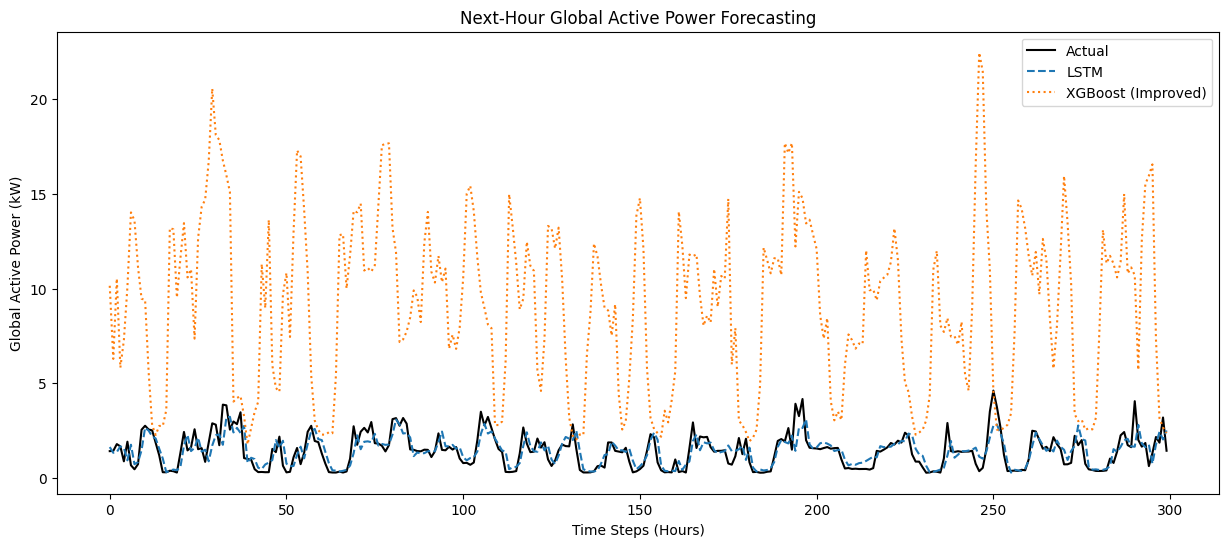

In [ ]:
#Visualization of Actual vs Predicted(LSTM vs XGBoost)

plt.figure(figsize=(15,6))
plt.plot(y_test_inv[:300], label='Actual', color='black')
plt.plot(y_pred_lstm_inv[:300], label='LSTM', linestyle='--')
plt.plot(y_pred_xgb_feat_inv[:300], label='XGBoost (Improved)', linestyle=':')
plt.title("Next-Hour Global Active Power Forecasting")
plt.xlabel("Time Steps (Hours)")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()


## **Conclusion:**

- On this dataset, LSTM performs noticeably better than XGBoost.

- Long-range dependencies help neural networks better capture temporal patterns.

- Even with the addition of engineered features, XGBoost was unable to match LSTM in capturing temporal dependencies.

- Given that LSTM can model sequential dependencies and XGBoost lacks time awareness, this is to be expected.

- Deep learning models like LSTM are frequently superior options for time-series forecasting tasks where sequence and trends are important.


## Feature Analysis and Anomaly Detection

## Goal
To find odd energy spikes or drops, look for unusual power consumption patterns in household data. Beyond what is revealed by conventional forecasting, this can offer more profound insight into anomalous behaviour.

### Method:
- Determine the standard deviation and rolling mean (window = 24 hours).
- Determine each point's Z-score using this rolling window.
- Any point where |Z| > 3 should be marked as abnormal.

This straightforward statistical technique is helpful for identifying **drops or spikes in relation to local trends**.

### Anomaly Detection
- Z-score Based Anomaly Detection were identified with rolling Z-scores (> 3 std deviations).

- This approaches uncovered outliers and potential external anomalies (e.g., appliances, seasons).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Reuse hourly dataset
df_anomaly = df_hourly[['Global_active_power']].copy()

# Step 1: Rolling Z-score Anomaly Detection
window = 24
df_anomaly['rolling_mean'] = df_anomaly['Global_active_power'].rolling(window).mean()
df_anomaly['rolling_std'] = df_anomaly['Global_active_power'].rolling(window).std()
df_anomaly['z_score'] = (df_anomaly['Global_active_power'] - df_anomaly['rolling_mean']) / df_anomaly['rolling_std']
df_anomaly['anomaly_zscore'] = df_anomaly['z_score'].abs() > 3

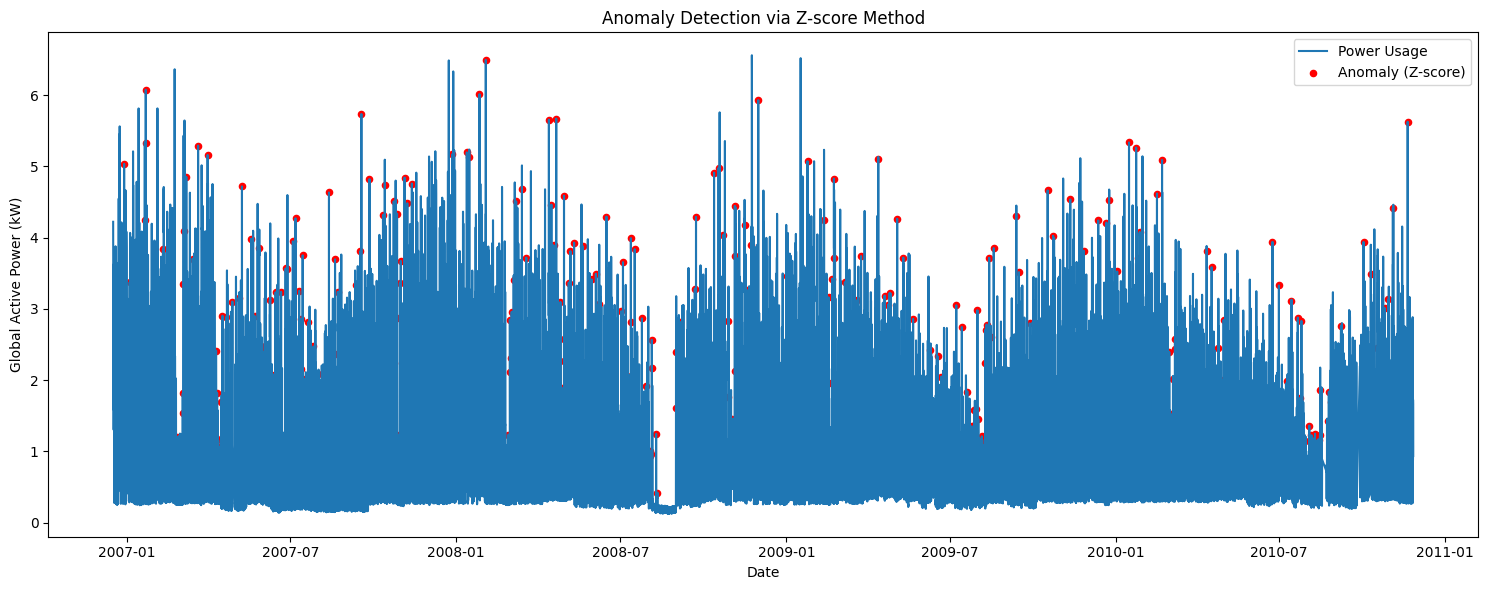

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(df_anomaly.index, df_anomaly['Global_active_power'], label='Power Usage')
plt.scatter(df_anomaly[df_anomaly['anomaly_zscore']].index,
            df_anomaly[df_anomaly['anomaly_zscore']]['Global_active_power'],
            color='red', label='Anomaly (Z-score)', s=20)
plt.title('Anomaly Detection via Z-score Method')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

- Blue line: Actual energy consumption
- Red dots: Detected anomalies

### Key Insights

-The majority of anomalies happen during **sudden surges or dips**, which could mean:
  - A malfunctioning piece of equipment
  - Power-hungry devices
  - Disconnections that are temporary

A number of **early morning and evening anomalies** that we notice could be signs of erratic usage patterns.
A few anomalies with high Z-scores are associated with **peak hours** and potential device issues.

By highlighting **rare, extreme events** in the dataset, anomaly detection enhances forecasting. Rolling Z-score was straightforward but efficient.


## Model Improvement Based on Anomaly Filtering
- From **the feature-analysis section** we identified  anomaly detection now we will improve the LSTM model from the initial modeling section so that anomalies don't have a detrimental effect on training.
- Utilising Z-score Anomalies to Clean the Training Set:

  - Anomalies were eliminated from the training set.
  - Kept the entire test set for a fair comparison.
- Retrain the LSTM using the cleaned data:
  - The same architecture was used to retrain LSTM.
- Performance comparison with the original LSTM


In [ ]:
# Define train/test split boundaries for df_anomaly DataFrame
from math import sqrt
total_len = len(df_anomaly)
split_idx = int(total_len * 0.8)
train_end = df_anomaly.index[split_idx - 1]  # last timestamp in training set
test_start = df_anomaly.index[split_idx]     # first timestamp in test set

# Step 1: Remove Z-score anomalies from training set
df_train_cleaned = df_anomaly.loc[:train_end].copy()
df_train_cleaned = df_train_cleaned[~df_train_cleaned['anomaly_zscore']]  # remove anomalies

# Combine cleaned training with untouched test set
df_combined_cleaned = pd.concat([df_train_cleaned, df_anomaly.loc[test_start:]], axis=0)

# Helper function to create supervised lag dataset
def create_supervised_data_cleaned(data, n_lags=24):
    df_supervised = pd.DataFrame()
    for i in range(n_lags, len(data)):
        X = data['Global_active_power'].values[i-n_lags:i]
        y = data['Global_active_power'].values[i]
        row = list(X) + [y]
        df_supervised = pd.concat([df_supervised, pd.DataFrame([row])])
    df_supervised.columns = [f'lag_{i}' for i in range(n_lags, 0, -1)] + ['target']
    df_supervised.index = data.index[n_lags:]
    return df_supervised

df_supervised_clean = create_supervised_data_cleaned(df_combined_cleaned)

# Train-test split on supervised dataset
X_clean = df_supervised_clean.drop('target', axis=1).values
y_clean = df_supervised_clean['target'].values

split_idx_supervised = int(len(df_supervised_clean) * 0.8)
X_train_clean, X_test_clean = X_clean[:split_idx_supervised], X_clean[split_idx_supervised:]
y_train_clean, y_test_clean = y_clean[:split_idx_supervised], y_clean[split_idx_supervised:]

# Reshape input for LSTM: (samples, timesteps, features)
X_train_clean_lstm = X_train_clean.reshape((X_train_clean.shape[0], X_train_clean.shape[1], 1))
X_test_clean_lstm = X_test_clean.reshape((X_test_clean.shape[0], X_test_clean.shape[1], 1))

# Step 2: Build and train LSTM model on cleaned data
lstm_model_cleaned = Sequential()
lstm_model_cleaned.add(LSTM(50, activation='tanh', input_shape=(X_train_clean_lstm.shape[1], 1)))
lstm_model_cleaned.add(Dense(1))
lstm_model_cleaned.compile(optimizer='adam', loss='mse')

history_cleaned = lstm_model_cleaned.fit(X_train_clean_lstm, y_train_clean,
                                         validation_split=0.2, epochs=20, batch_size=32, verbose=0)

# Step 3: Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_cleaned = lstm_model_cleaned.predict(X_test_clean_lstm).flatten()
mae_cleaned = mean_absolute_error(y_test_clean, y_pred_cleaned)
rmse_cleaned = sqrt(mean_squared_error(y_test_clean, y_pred_cleaned))

# Compare with original LSTM performance (replace mae_lstm, rmse_lstm with your original values)
print("Original LSTM Performance (with anomalies):")
print(f"MAE: {mae_lstm:.6f}, RMSE: {rmse_lstm:.6f}")
print("Cleaned LSTM Performance (without anomalies):")
print(f"MAE: {mae_cleaned:.6f}, RMSE: {rmse_cleaned:.6f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Original LSTM Performance (with anomalies):
MAE: 0.368721, RMSE: 0.514295
Cleaned LSTM Performance (without anomalies):
MAE: 0.357996, RMSE: 0.509041


### Performance Comparison

| Model                             | MAE       | RMSE      |
|----------------------------------|-----------|-----------|
| **Original LSTM (with anomalies)**   | **0.368721**  | **0.514295**  |
| **Cleaned LSTM (without anomalies)** | **0.357996**  | **0.509041**  |

- We enhanced our LSTM forecasting model by eliminating anomalous data points (based on Z-score) from the training set using from anomaly detection (the feature-analysis section).  That this would enhance generalisation and lessen the impact of outliers on model training.


### Final Visualization
- Plot comparison between the original and cleaned LSTM predictions
- The cleaned LSTM model exhibits marginally better accuracy and stability in the graph below, particularly during abrupt fluctuations. With a noticeable improvement in MAE,RMSE, the overall error is decreased, suggesting improved management of significant deviations.


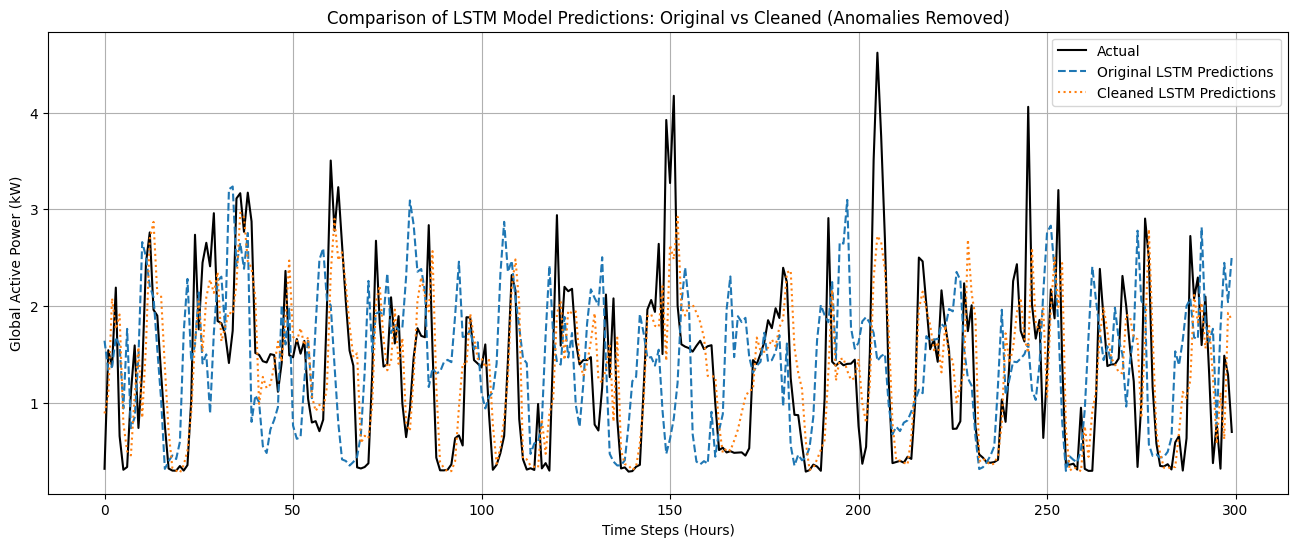

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_len = 300

plt.figure(figsize=(16,6))

plt.plot(y_test_clean[:plot_len], label='Actual', color='black')
plt.plot(y_pred_lstm_inv[:plot_len], label='Original LSTM Predictions', linestyle='--')
plt.plot(y_pred_cleaned[:plot_len], label='Cleaned LSTM Predictions', linestyle=':')

plt.title('Comparison of LSTM Model Predictions: Original vs Cleaned (Anomalies Removed)')
plt.xlabel('Time Steps (Hours)')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show()


### Conclusion

- The slightly improved performance of the cleaned model validates the value of anomaly filtering in training data.

- Because LSTM excels at modelling sequential dependencies, it was the ideal option for this dataset.

- While tree-based models, such as XGBoost, have rich features, they don't have time memory.

- There were clear seasonal trends.
- **Future improvement may include:**

  - Using hybrid models or external features can result in further advancements.
